## Load essential libraries

In [1]:
import os
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import time
from collections import Counter
import warnings

%matplotlib inline
plt.style.use('ggplot')

import sys
sys.path.insert(0, os.path.join(os.path.expanduser('~'), 'Desktop', 'miner3', 'miner', 'src'))
import miner_py3 as miner

## Define functions for state inference

In [2]:
def louvain(matrix,min_cluster_size=1,rbf=True,distance_matrix=False):
    
    import numpy as np
    import pandas as pd
    import community
    import networkx as nx
    from scipy.spatial.distance import cdist
    from sklearn.metrics.pairwise import rbf_kernel, laplacian_kernel
    
    df = False  # FIX: initialize to avoid NameError when matrix is not a DataFrame
    if type(matrix) is pd.core.frame.DataFrame:
        df = True
        columns = matrix.columns
        matrix = np.array(matrix)
       
    n = matrix.shape[0]
    
    if distance_matrix is False:
        if rbf is True:
            distance_matrix = rbf_kernel(matrix.T,gamma=None)
        elif rbf is False:
            distance_matrix = laplacian_kernel(matrix.T,gamma=None)
    elif distance_matrix is True:
        distance_matrix = matrix
    
    max_distance = float(np.amax(distance_matrix))

    elist = []
    for i in range(distance_matrix.shape[0]):
        for j in range(i,distance_matrix.shape[0]):
            elist.append((i,j,distance_matrix[i,j]/max_distance))

    G = nx.Graph()
    G.add_weighted_edges_from(elist)

    partition = community.best_partition(G)

    louvain_clusters = {}
    for name in list(partition.keys()):
        value = partition[name]
        if value not in list(louvain_clusters.keys()):
            louvain_clusters[value] = []
        louvain_clusters[value].append(name)

    if df is True:
        louvain_list = [list(columns[louvain_clusters[key]]) for key in list(louvain_clusters.keys())]
    else:
        louvain_list = [list(louvain_clusters[key]) for key in list(louvain_clusters.keys())]
        
    return louvain_list

## Define paths to data and results

In [3]:
# Path to the miner directory
input_path = os.path.join(os.path.expanduser('~'),'Desktop','miner3','miner')

# name of results folder
resultsFolder = "TCGA_UVM_state_clustering_results"

# name of the folder containing the miner network
networkFolder = "TCGA_UVM_network_results"

# create results directory
resultsDirectory = os.path.join(input_path, resultsFolder)
if not os.path.isdir(resultsDirectory):
    os.mkdir(resultsDirectory)

In [4]:
import glob
files = glob.glob(os.path.expanduser("~/Desktop/miner3/**/identifier_mappings*"), recursive=True)
for f in files:
    print(f)

/Users/sanskrutik/Desktop/miner3/miner/data/identifier_mappings.txt


## Load network data

In [5]:
# Load expression Data
expressionFile = os.path.join(input_path,"data","expression","TCGA_UVM","TCGA_UVM_Zscore.csv")
expressionData = pd.read_csv(expressionFile, index_col=0, header=0)

revisedClusters = miner.read_json(os.path.join(input_path,networkFolder,"coexpressionDictionary.json"))
coexpressionModules = miner.read_json(os.path.join(input_path,networkFolder,"coexpressionModules.json"))
regulonModules = miner.read_json(os.path.join(input_path,networkFolder,"regulons.json"))
mechanisticOutput = miner.read_json(os.path.join(input_path,networkFolder,"mechanisticOutput.json"))
regulonDf = pd.read_csv(os.path.join(input_path,networkFolder,"regulonDf.csv"),index_col=0,header=0)
overExpressedMembersMatrix = pd.read_csv(os.path.join(input_path,networkFolder,"overExpressedMembers.csv"),index_col=0,header=0)
overExpressedMembersMatrix.index = np.array(overExpressedMembersMatrix.index).astype(str)
underExpressedMembersMatrix = pd.read_csv(os.path.join(input_path,networkFolder,"underExpressedMembers.csv"),index_col=0,header=0)
underExpressedMembersMatrix.index = np.array(underExpressedMembersMatrix.index).astype(str)
eigengenes = pd.read_csv(os.path.join(input_path,networkFolder,"eigengenes.csv"),index_col=0,header=0)
eigengenes.index = np.array(underExpressedMembersMatrix.index).astype(str)

In [6]:
# Cell 5B: Convert ENSG IDs -> Gene Symbols
mapping_file = os.path.join(input_path, "data", "identifier_mappings.txt")
mapping_df = pd.read_csv(mapping_file, sep="\t")
# Same mapping used in miner_generate_network.ipynb
gene_name_rows = mapping_df[mapping_df["Source"] == "Gene Name"]
ensembl_to_symbol = dict(
    zip(gene_name_rows["Preferred_Name"],
        gene_name_rows["Name"])
)
# Remove missing mappings
ensembl_to_symbol = {
    k: v for k, v in ensembl_to_symbol.items()
    if pd.notna(k) and pd.notna(v)
}
# Convert ENSG IDs to symbols
def lookup_symbol(ensembl_id):
    bare = str(ensembl_id).split('.')[0]
    return ensembl_to_symbol.get(bare, bare)
expressionData.index = [
    lookup_symbol(g)
    for g in expressionData.index
]
# Remove duplicate gene symbols
expressionData = expressionData[
    ~expressionData.index.duplicated(keep='first')
]
print("ExpressionData sample:")
print(expressionData.index[:10].tolist())

ExpressionData sample:
['5S_rRNA', '7SK', 'A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A2ML1-AS1', 'A2ML1-AS2']


### IMPORTANT:
##### miner_generate_network.ipynb converts ENSG IDs to gene symbols before building regulons. The same conversion must be applied here before program membership analysis.

In [7]:
t1 = time.time()
# select reference dictionary for downstream analysis (revisedClusters, coexpressionModules, or regulonModules)
referenceDictionary = regulonModules
# create a background matrix used for statistical hypothesis testing
bkgd = miner.backgroundDf(expressionData)
# for each cluster, give samples that show high coherent cluster activity
overExpressedMembers = miner.biclusterMembershipDictionary(referenceDictionary,bkgd,label=2,p=0.05)
# for each clus|ter, give samples that show low coherent cluster activity
underExpressedMembers = miner.biclusterMembershipDictionary(referenceDictionary,bkgd,label=0,p=0.05)

# write membership matrices to .csv file
overExpressedMembersMatrix = miner.membershipToIncidence(overExpressedMembers,expressionData)
overExpressedMembersMatrix.to_csv(os.path.join(resultsDirectory,"overExpressedMembers.csv"))
underExpressedMembersMatrix = miner.membershipToIncidence(underExpressedMembers,expressionData)
underExpressedMembersMatrix.to_csv(os.path.join(resultsDirectory,"underExpressedMembers.csv"))

t2 = time.time()
print("Completed patient mapping in {:.2f} minutes".format((t2-t1)/60.))

/Users/sanskrutik/Desktop/miner3/miner/src/miner_py3.py:1058: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  bkgd.iloc[:,i][bkgd.iloc[:,i]>=highCut]=1
/Users/sanskrutik/Desktop/miner3/miner/src/miner_py3.py:1059: FutureWarning: ChainedAssignm

done!
done!
Completed patient mapping in 0.13 minutes


In [8]:
# Load transcriptional programs
transcriptional_programs = miner.read_json(os.path.join(input_path,networkFolder,'transcriptional_programs.json'))
program_list = [transcriptional_programs[str(key)] for key in range(len(transcriptional_programs.keys()))]

# Load transcriptional states
transcriptional_states = miner.read_json(os.path.join(input_path,networkFolder,'transcriptional_states.json'))
states_list = [transcriptional_states[str(key)] for key in range(len(transcriptional_states.keys()))]

# Filter each state to only samples present in expressionData
expr_cols = set(expressionData.columns)
states_list = [
    list(dict.fromkeys([s for s in state if s in expr_cols]))
    for state in states_list
]
# Remove any states that became empty after filtering
states_list = [s for s in states_list if len(s) > 0]

# Verify
all_state_samples = set(np.hstack(states_list))
print("States NOT in expressionData:", len(all_state_samples - expr_cols))  # Must be 0
print("State sizes:", [len(s) for s in states_list])

final_state = list(set(expressionData.columns)-set(np.hstack(states_list)))
if len(final_state)>0:
    states_list.append(final_state)
states = states_list.copy()
diff_matrix_MMRF = overExpressedMembersMatrix-underExpressedMembersMatrix

states_df = pd.DataFrame(np.zeros((len(states),expressionData.shape[1])))
states_df.index = list(range(1,len(states)+1))
states_df.columns = expressionData.columns

for i in range(len(states)):
    states_df.loc[i+1,states[i]] = 1

state_labels = pd.DataFrame(np.zeros((expressionData.shape[1],1)))
state_labels.index = expressionData.columns
state_labels.columns = ["state"]
for j in range(states_df.shape[0]):
    s = states_df.index[j]
    state_labels.loc[states[j],"state"] = int(s)

state_labels.head()
state_labels.to_csv(os.path.join(resultsDirectory, "state_labels.csv"))

States NOT in expressionData: 0
State sizes: [21, 14, 25, 1, 18, 1]


In [9]:
# Create dictionary of program genes
# make dictionary of genes by program
pr_genes = {}
for i in range(len(program_list)):
    rgns = program_list[i]
    genes = []
    for r in rgns:
        genes.append(regulonModules[r])
    genes = list(set(np.hstack(genes)))
    pr_genes[i] = genes

In [10]:
# select reference dictionary for downstream analysis (revisedClusters, coexpressionModules, or regulonModules)
referenceDictionary = pr_genes
# create a background matrix used for statistical hypothesis testing
bkgd = miner.backgroundDf(expressionData)
# for each cluster, give samples that show high coherent cluster activity
overExpressedMembers_pr = miner.biclusterMembershipDictionary(referenceDictionary,bkgd,label=2,p=0.05)
# for each clus|ter, give samples that show low coherent cluster activity
underExpressedMembers_pr = miner.biclusterMembershipDictionary(referenceDictionary,bkgd,label=0,p=0.05)
# for each cluster, give samples that do not show coherent cluster activity
# dysregulatedMembers = miner.biclusterMembershipDictionary(referenceDictionary,bkgd,label="excluded")
# # for each cluster, give samples that show coherent cluster activity, despite magnitude of expression
# coherentMembers = miner.biclusterMembershipDictionary(referenceDictionary,bkgd,label="included")

# write membership matrices to .csv file
overExpressedProgramsMatrix_pr = miner.membershipToIncidence(overExpressedMembers_pr,expressionData)
#overExpressedMembersMatrix.to_csv(os.path.join(resultsDirectory,"overExpressedMembers.csv"))
underExpressedProgramsMatrix_pr = miner.membershipToIncidence(underExpressedMembers_pr,expressionData)
#underExpressedMembersMatrix.to_csv(os.path.join(resultsDirectory,"underExpressedMembers.csv"))

# Generate program activity difference matrix
dfr_pr = overExpressedProgramsMatrix_pr - underExpressedProgramsMatrix_pr

/Users/sanskrutik/Desktop/miner3/miner/src/miner_py3.py:1058: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  bkgd.iloc[:,i][bkgd.iloc[:,i]>=highCut]=1
/Users/sanskrutik/Desktop/miner3/miner/src/miner_py3.py:1059: FutureWarning: ChainedAssignm

done!
done!


In [11]:
print("Non-zero over:",
      np.count_nonzero(overExpressedProgramsMatrix_pr.values))

print("Non-zero under:",
      np.count_nonzero(underExpressedProgramsMatrix_pr.values))

print("Non-zero dfr_pr:",
      np.count_nonzero(dfr_pr.values))

Non-zero over: 3586
Non-zero under: 2970
Non-zero dfr_pr: 6556


## UMAP

UMAP(min_dist=0.25, verbose=True)
Thu Jul  9 15:51:20 2026 Construct fuzzy simplicial set
Thu Jul  9 15:51:20 2026 Finding Nearest Neighbors
Thu Jul  9 15:51:21 2026 Finished Nearest Neighbor Search
Thu Jul  9 15:51:22 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Thu Jul  9 15:51:22 2026 Finished embedding


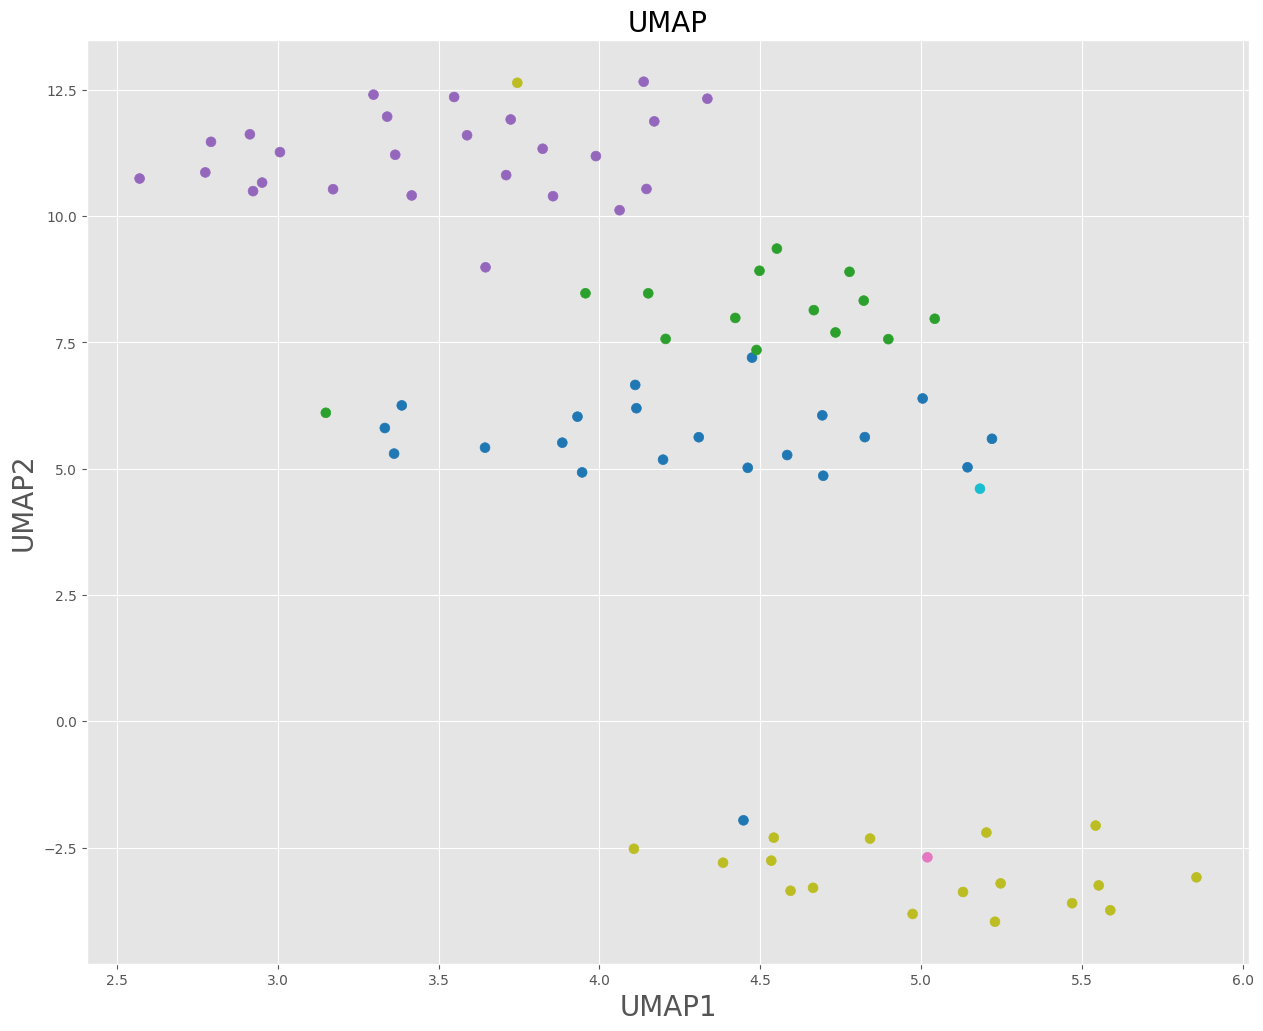

In [12]:
from umap import UMAP
plt.figure(figsize=(15,12))
model = UMAP(n_neighbors = 15, min_dist = 0.25, n_components = 2, verbose = True)

X_train = diff_matrix_MMRF.T

umap = model.fit_transform(X_train)
plt.scatter(umap[:, 0], umap[:, 1], c = np.array(state_labels.iloc[:,0]).astype(int),cmap = 'tab10', s = 50) #c = y_train.astype(int)
plt.title('UMAP', fontsize = 20)
plt.xlabel("UMAP1", fontsize = 20)
plt.ylabel("UMAP2", fontsize = 20)
plt.savefig(os.path.join(resultsDirectory, 'umap_transcriptional_states.png'), 
            format='png', dpi=150, bbox_inches='tight')
plt.show()

## Method 1: HDBSCAN

In [13]:
import sys
!{sys.executable} -m pip install hdbscan


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [14]:
import hdbscan

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets as data
%matplotlib inline
sns.set_context('poster')
sns.set_style('white')
sns.set_color_codes()
plot_kwds = {'alpha' : 0.5, 's' : 80, 'linewidths':0}

In [16]:
#Cluster with HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=3, min_samples=1, 
                              gen_min_span_tree=True, prediction_data=True,
                              cluster_selection_epsilon=0.5)
clusterer.fit(umap)
print(f"Clusters found: {len(set(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0)}")
print(f"Noise points: {np.sum(clusterer.labels_ == -1)}")

Clusters found: 2
Noise points: 0


<Axes: >

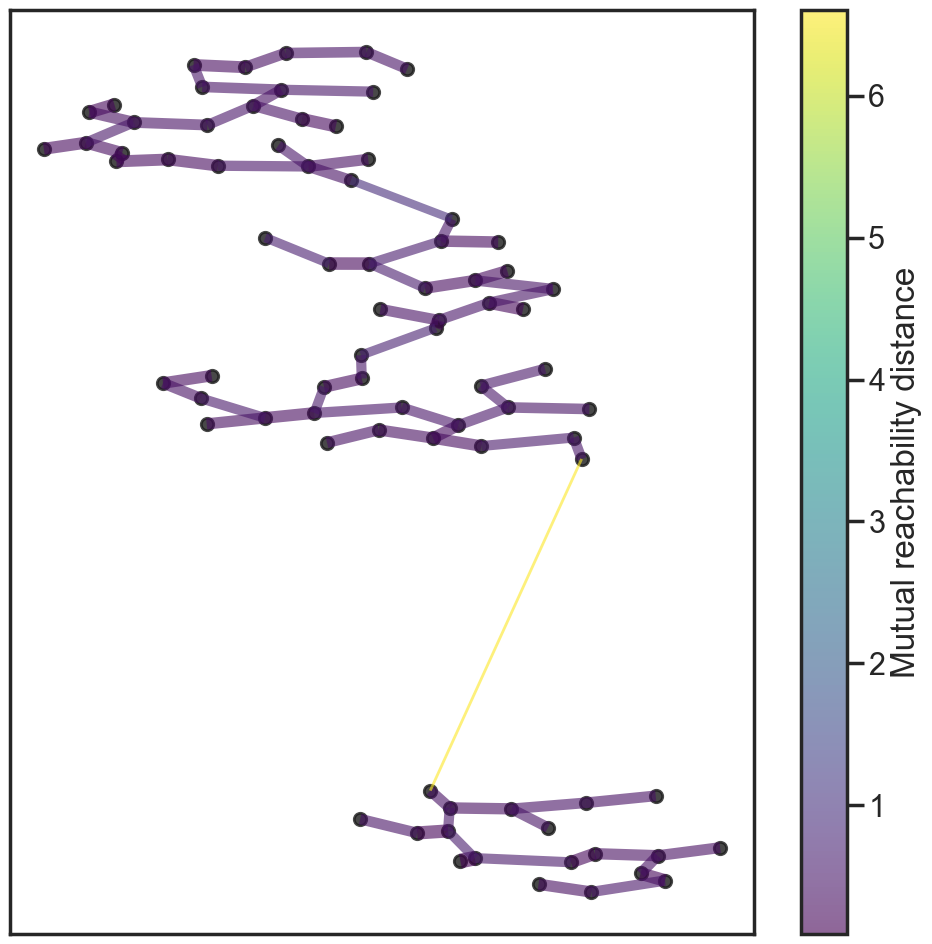

In [17]:
plt.figure(figsize=(12,12))
clusterer.minimum_spanning_tree_.plot(edge_cmap='viridis',
                                      edge_alpha=0.6,
                                      node_size=80,
                                      edge_linewidth=2)

<Axes: ylabel='distance'>

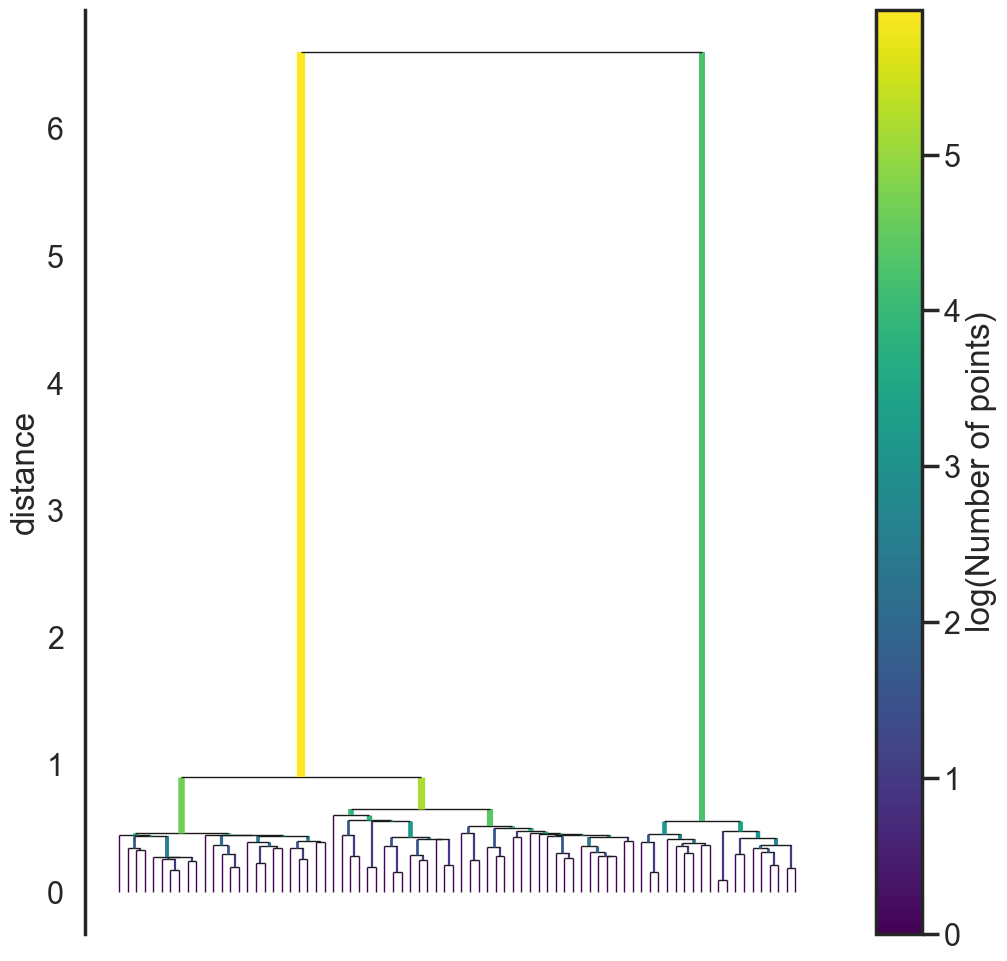

In [18]:
plt.figure(figsize=(12,12))
clusterer.single_linkage_tree_.plot(cmap='viridis', colorbar=True)

<Axes: ylabel='$\\lambda$ value'>

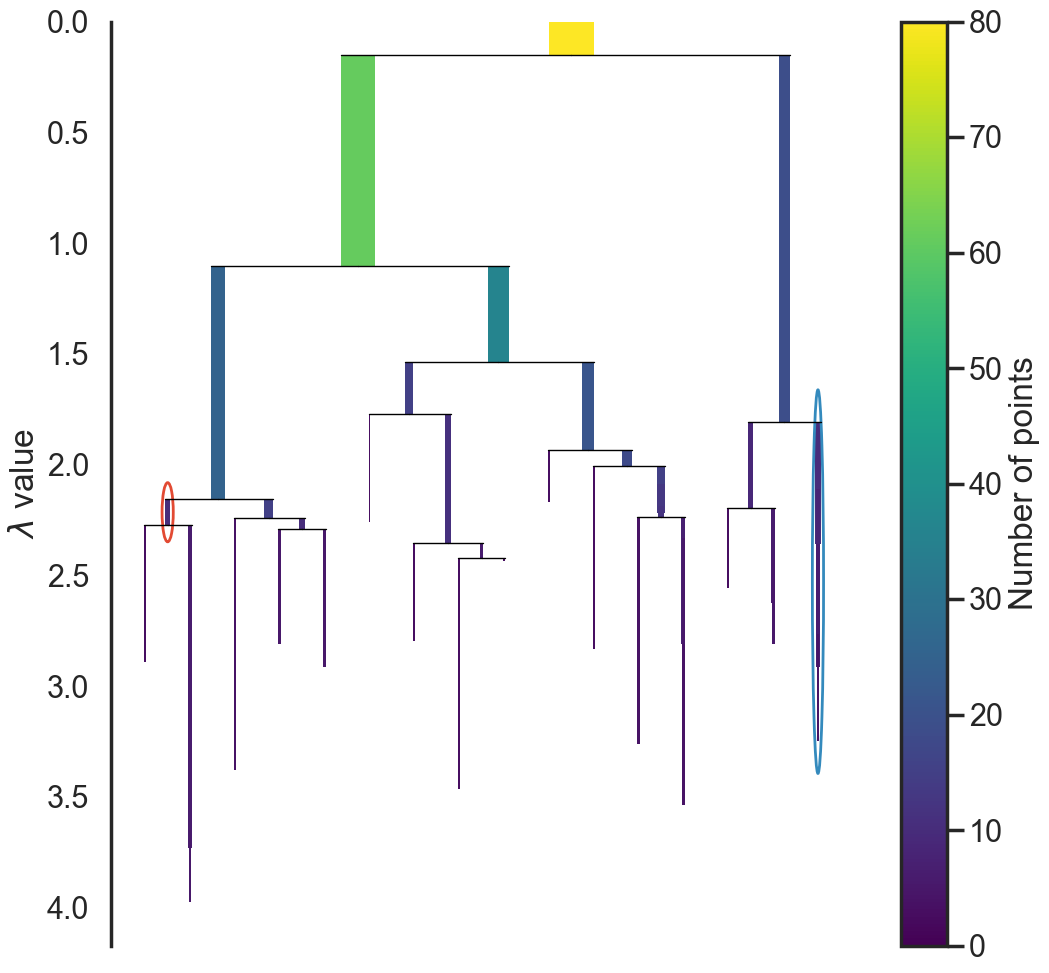

In [19]:
plt.figure(figsize=(12,12))
clusterer.condensed_tree_.plot(select_clusters=True, selection_palette=sns.color_palette())

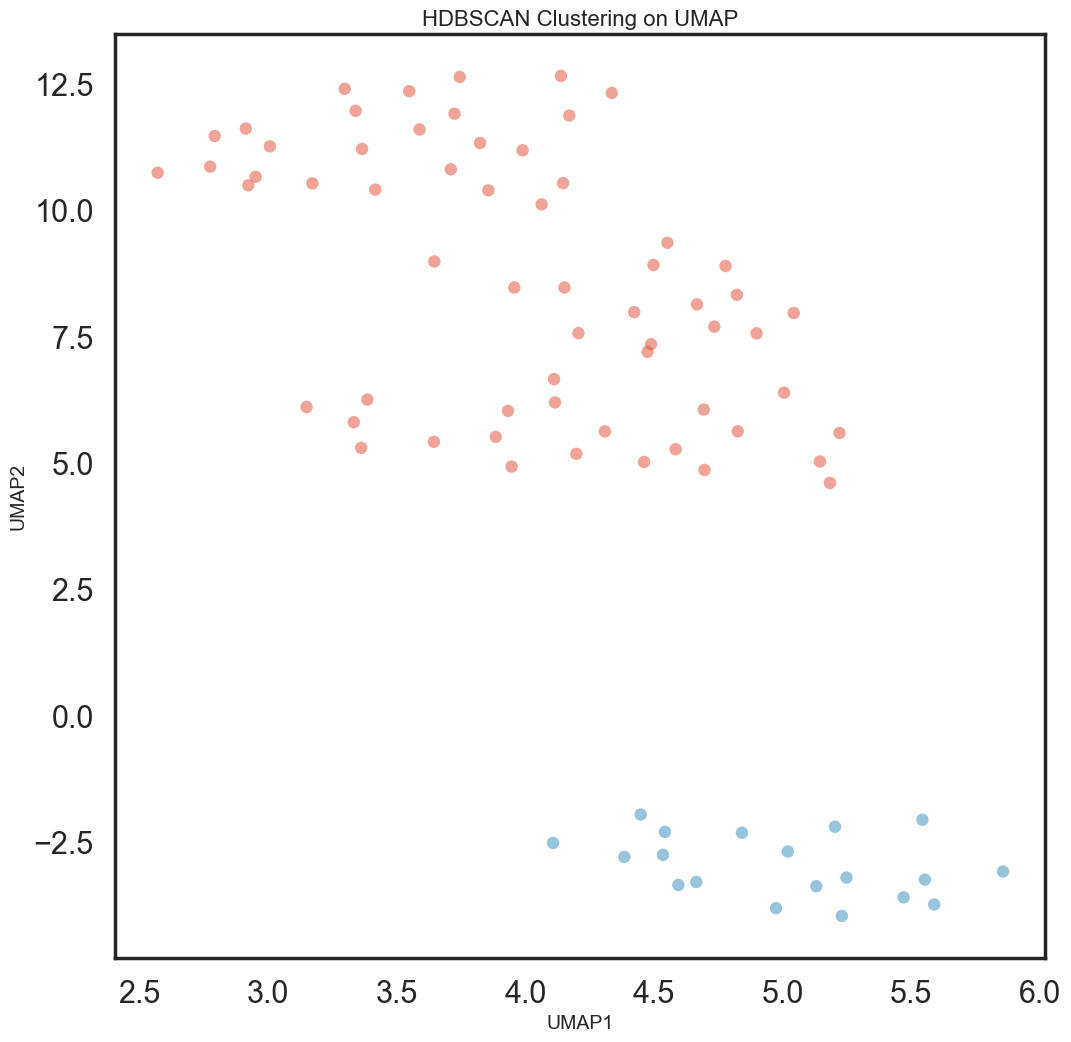

In [20]:
plt.figure(figsize=(12,12))
palette = sns.color_palette()
# FIX: map -1 (noise) to grey to avoid colormap ValueError
cluster_colors = [palette[col % len(palette)] if col >= 0 else (0.5, 0.5, 0.5)
                  for col in clusterer.labels_]
plt.scatter(umap.T[0], umap.T[1], c=cluster_colors, **plot_kwds)
plt.title("HDBSCAN Clustering on UMAP", fontsize=16)
plt.xlabel("UMAP1", fontsize=14)
plt.ylabel("UMAP2", fontsize=14)
plt.show()

In [21]:
hdbscan_results = pd.DataFrame(clusterer.labels_)
hdbscan_results.columns = ["cluster"]
# FIX: use expressionData.columns — eigengenes.columns may not match UMAP row count
hdbscan_results.index = dfr_pr.columns

In [22]:
hdbscan_states = []
for c in hdbscan_results.cluster.unique():
    # FIX: skip noise label (-1), these are ungrouped outliers
    if c == -1:
        continue
    tmp_state = hdbscan_results.index[np.where(hdbscan_results.iloc[:,0]==c)[0]]
    hdbscan_states.append(tmp_state)
print(f"Number of HDBSCAN states: {len(hdbscan_states)}")

Number of HDBSCAN states: 2


In [23]:
hdbscan_results.cluster.unique()

array([0, 1])

In [24]:
# Diagnostic
all_hdbscan_patients = np.hstack(hdbscan_states)
print(f"HDBSCAN patients: {len(all_hdbscan_patients)}")
print(f"dfr_pr columns: {dfr_pr.shape[1]}")
print(f"dfr_pr rows: {dfr_pr.shape[0]}")

# Check overlap
overlap = [p for p in all_hdbscan_patients if p in dfr_pr.columns]
missing = [p for p in all_hdbscan_patients if p not in dfr_pr.columns]
print(f"Patients found in dfr_pr: {len(overlap)}")
print(f"Patients MISSING from dfr_pr: {len(missing)}")

# Check if values are actually zero
subset = dfr_pr.loc[:, overlap]
print(f"dfr_pr subset min: {subset.values.min():.4f}, max: {subset.values.max():.4f}")
print(f"Non-zero values: {np.count_nonzero(subset.values)}")

HDBSCAN patients: 80
dfr_pr columns: 80
dfr_pr rows: 101
Patients found in dfr_pr: 80
Patients MISSING from dfr_pr: 0
dfr_pr subset min: -1.0000, max: 1.0000
Non-zero values: 6556


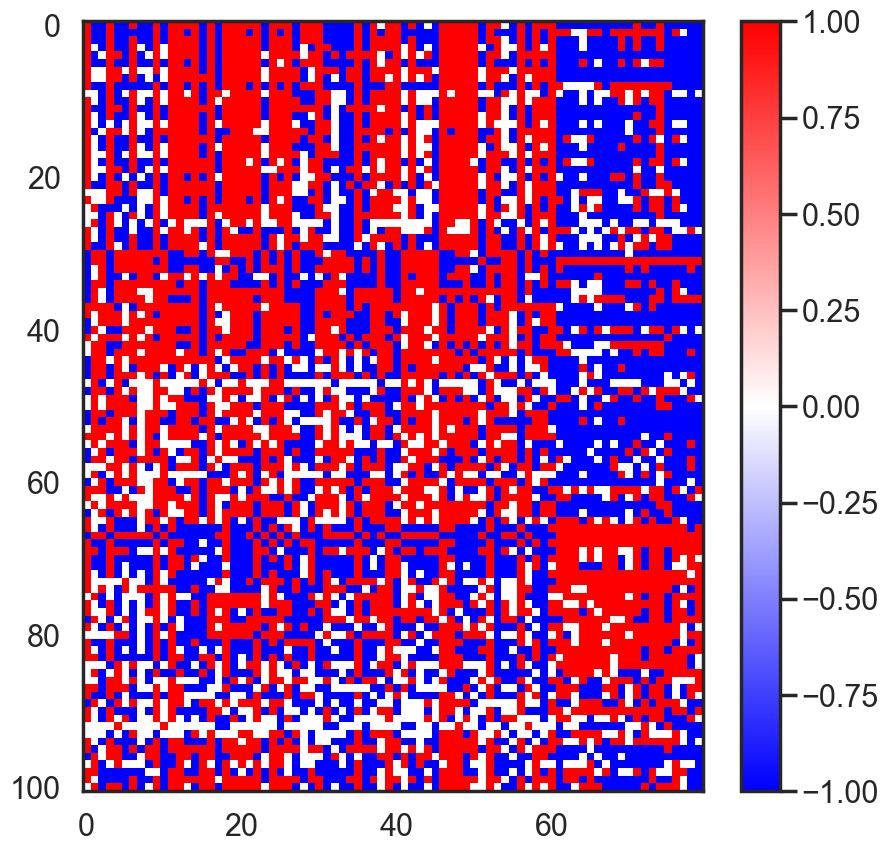

In [25]:
if len(hdbscan_states) == 0:
    print("WARNING: No HDBSCAN clusters found — all points classified as noise. Tune min_cluster_size/min_samples.")
else:
    plt.figure(figsize=(10,10))
    plt.imshow(dfr_pr.loc[:, np.hstack(hdbscan_states)], aspect="auto", cmap="bwr")
    plt.colorbar()
    plt.savefig(os.path.join(resultsDirectory, 'hdbscan_states.png'), format='png', dpi=150, bbox_inches='tight')
    plt.show()

## Method 2: Louvain

In [26]:
import sys
sys.path.insert(0, os.path.join(input_path, 'src'))
from miner_py3 import sampleCoincidenceMatrix

In [27]:
#Generate similarity matrix for over-expressed members
scm_over = sampleCoincidenceMatrix(overExpressedMembers,frequencies=True)
over_sim_mat = scm_over*scm_over.T

#Generate similarity matrix for under-expressed members
scm_under = sampleCoincidenceMatrix(underExpressedMembers,frequencies=True)
under_sim_mat = scm_under*scm_under.T

In [28]:
print("over_sim_mat shape:", over_sim_mat.shape)
print("expressionData columns:", expressionData.shape[1])
print("Column match:", set(over_sim_mat.columns) == set(expressionData.columns))

over_sim_mat shape: (80, 80)
expressionData columns: 80
Column match: True


In [29]:
#Define matrix for clustering
data_for_clustering = over_sim_mat
alternative_data = under_sim_mat
data_for_plotting = diff_matrix_MMRF
min_size = 5
use_rbf = False
dist_mat = True

Primary Louvain clusters: 4


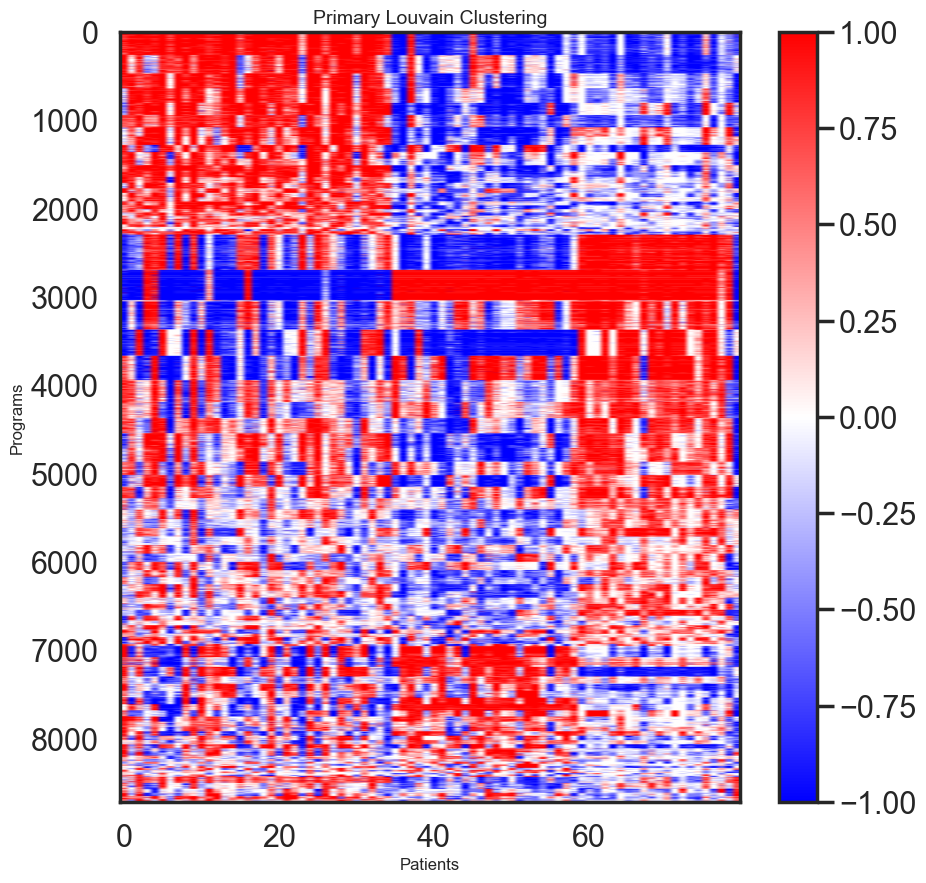

In [30]:
#Primary clustering
louvain_primary = louvain(data_for_clustering,min_cluster_size=min_size,rbf=use_rbf,distance_matrix=dist_mat)
print(f"Primary Louvain clusters: {len(louvain_primary)}")
plt.figure(figsize=(10,10))
plt.imshow(data_for_plotting.loc[np.hstack(program_list),np.hstack(louvain_primary)],aspect="auto",cmap="bwr")
plt.colorbar()
plt.title("Primary Louvain Clustering", fontsize=14)
plt.xlabel("Patients", fontsize=12)
plt.ylabel("Programs", fontsize=12)
plt.grid(False)
plt.show()

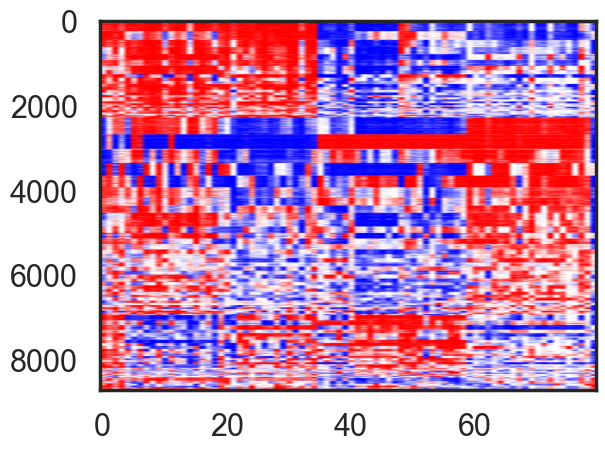

In [31]:
#Louvain sub-clustering on clusters of previous step
louvain_secondary = []
for c in louvain_primary:
    tmp_clusters = louvain(data_for_clustering.loc[c,c],min_cluster_size=min_size,
                           rbf=use_rbf,distance_matrix = dist_mat)
    louvain_secondary.extend(tmp_clusters)
    
plt.imshow(data_for_plotting.loc[np.hstack(program_list),np.hstack(louvain_secondary)],
           aspect="auto",cmap="bwr")

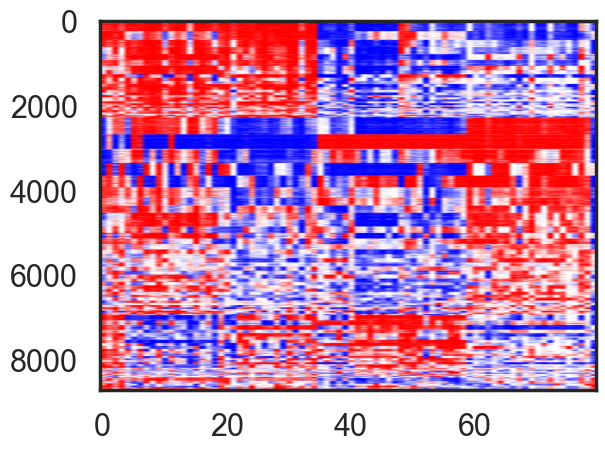

In [32]:
#Louvain sub-clustering on clusters of previous step
louvain_tertiary = []
for c in louvain_secondary:
    tmp_clusters = louvain(data_for_clustering.loc[c,c],min_cluster_size=min_size,
                           rbf=use_rbf,distance_matrix = dist_mat)
    lens = [len(k) for k in tmp_clusters]
    if min(lens)<min_size:
        louvain_tertiary.append(c)
    else:
        louvain_tertiary.extend(tmp_clusters)
        
plt.imshow(data_for_plotting.loc[np.hstack(program_list),np.hstack(louvain_tertiary)],
           aspect="auto",cmap="bwr")

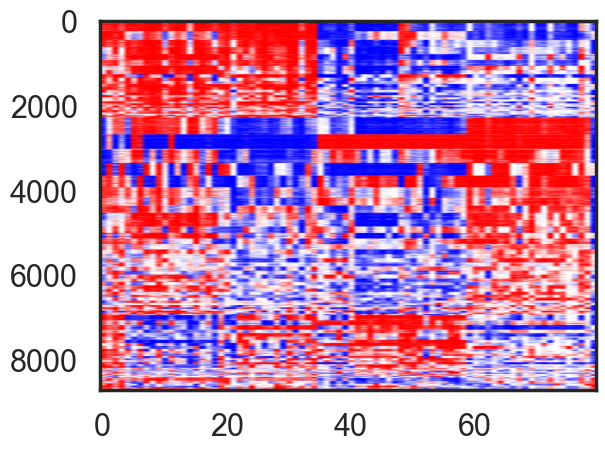

In [33]:
#Louvain sub-clustering on clusters of previous step
louvain_final = []
for c in louvain_tertiary:
    tmp_clusters = louvain(alternative_data.loc[c,c],min_cluster_size=min_size,
                           rbf=use_rbf,distance_matrix = dist_mat)
    lens = [len(k) for k in tmp_clusters]
    if min(lens)<min_size:
        louvain_final.append(c)
    else:
        louvain_final.extend(tmp_clusters)
        
plt.imshow(data_for_plotting.loc[np.hstack(program_list),np.hstack(louvain_final)],
           aspect="auto",cmap="bwr")

In [34]:
for i in range(len(states)):
    for j in range(len(louvain_final)):
        overlap = len(miner.intersect(louvain_final[j],states[i]))/float(min(len(louvain_final[j]),len(states[i])))
        if overlap >= 0.5:
            print("Louvain {:d} matches State {:d} with {:.2f}% overlap".format(i,j,100.0*overlap))

Louvain 0 matches State 0 with 75.00% overlap
Louvain 0 matches State 2 with 100.00% overlap
Louvain 0 matches State 3 with 100.00% overlap
Louvain 0 matches State 4 with 100.00% overlap
Louvain 1 matches State 1 with 92.86% overlap
Louvain 2 matches State 5 with 66.67% overlap
Louvain 2 matches State 10 with 100.00% overlap
Louvain 2 matches State 11 with 100.00% overlap
Louvain 2 matches State 12 with 100.00% overlap
Louvain 2 matches State 13 with 100.00% overlap
Louvain 2 matches State 14 with 100.00% overlap
Louvain 2 matches State 15 with 100.00% overlap
Louvain 2 matches State 16 with 100.00% overlap
Louvain 2 matches State 17 with 100.00% overlap
Louvain 2 matches State 18 with 100.00% overlap
Louvain 2 matches State 19 with 100.00% overlap
Louvain 3 matches State 9 with 100.00% overlap
Louvain 4 matches State 6 with 100.00% overlap
Louvain 4 matches State 7 with 66.67% overlap
Louvain 4 matches State 8 with 100.00% overlap
Louvain 4 matches State 9 with 80.00% overlap
Louvain 

## Method 3: Kmeans

In [35]:
# sim_mat is typically the combined similarity matrix
sim_mat = over_sim_mat + under_sim_mat

NaN values filled with 0: 0


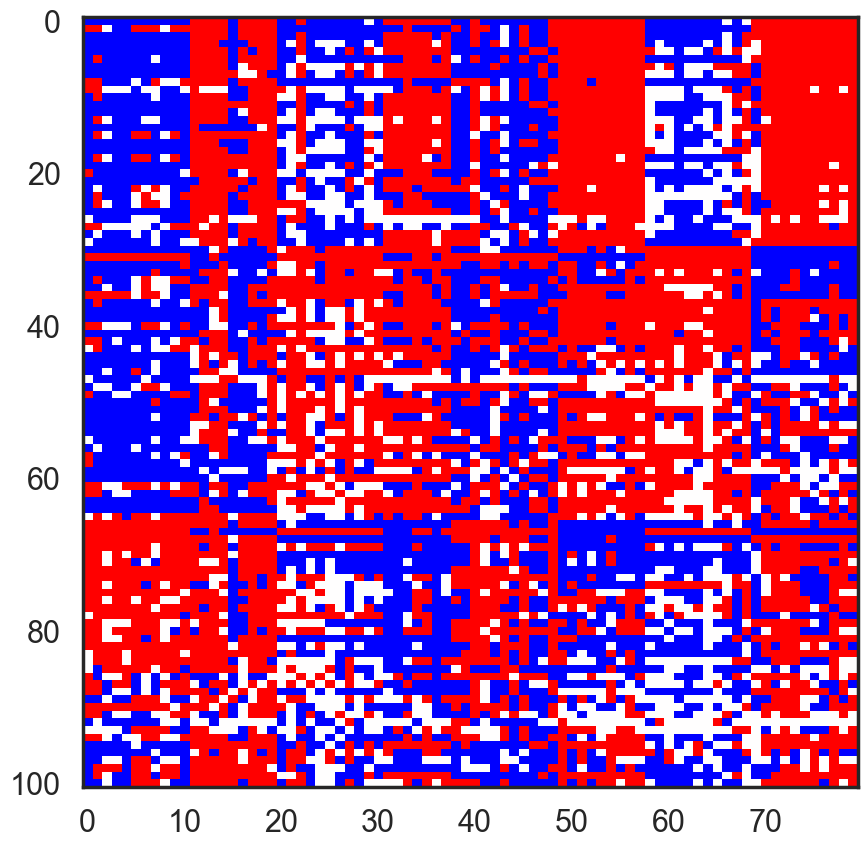

In [36]:
n_clusters = 8

# Fill NaNs before clustering — NaNs arise from empty clusters in similarity matrix
sim_mat_clean = (over_sim_mat + under_sim_mat).fillna(0)

# Check how many NaNs were filled
nan_count = (over_sim_mat + under_sim_mat).isna().sum().sum()
print(f"NaN values filled with 0: {nan_count}")

kmeans_states, labels, centroids = miner.kmeans(sim_mat_clean.T, n_clusters)
plt.figure(figsize=(10,10))
plt.imshow(dfr_pr.loc[:,np.hstack(kmeans_states)], aspect="auto", cmap="bwr")
plt.grid(False)

## Method 4: Hierarchical clustering

NaN values filled with 0: 0


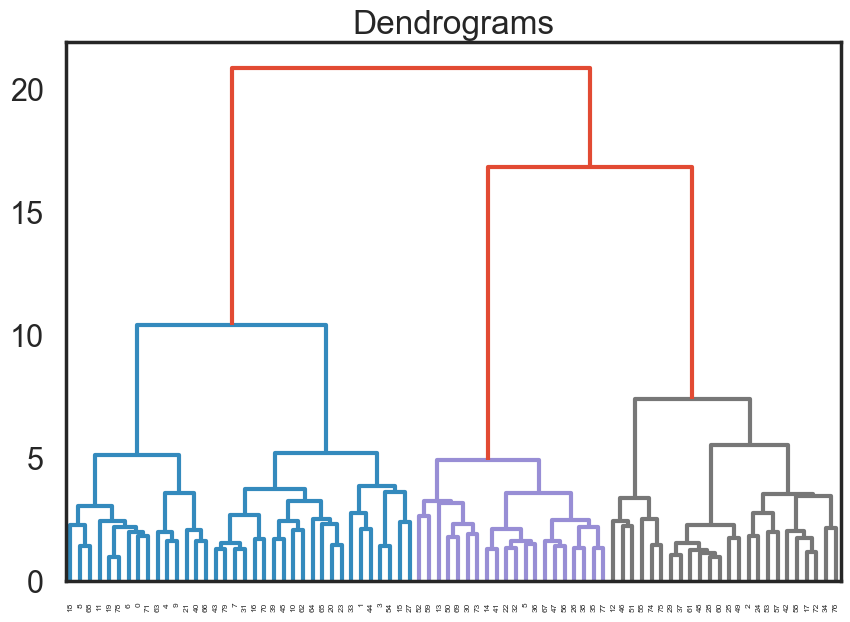

In [37]:
import scipy.cluster.hierarchy as shc

# Fill NaNs before clustering - NaNs arise from empty clusters in similarity matrix
sim_mat_clean = (over_sim_mat + under_sim_mat).fillna(0)

# Check how many NaNs were filled
nan_count = (over_sim_mat + under_sim_mat).isna().sum().sum()
print(f"NaN values filled with 0: {nan_count}")

plt.figure(figsize=(10, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(sim_mat_clean.T, method='ward'))

In [38]:
from sklearn.cluster import AgglomerativeClustering
n_clusters = 8
cluster = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
hierarchical_labels = pd.DataFrame(cluster.fit_predict(dfr_pr.T))
hierarchical_labels.index = eigengenes.columns
hierarchical_labels.columns = ["cluster"]


In [39]:
hierarchical_states = []
for c in hierarchical_labels.cluster.unique():
    tmp_state = hierarchical_labels.index[np.where(hierarchical_labels.iloc[:,0]==c)[0]]
    hierarchical_states.append(tmp_state)

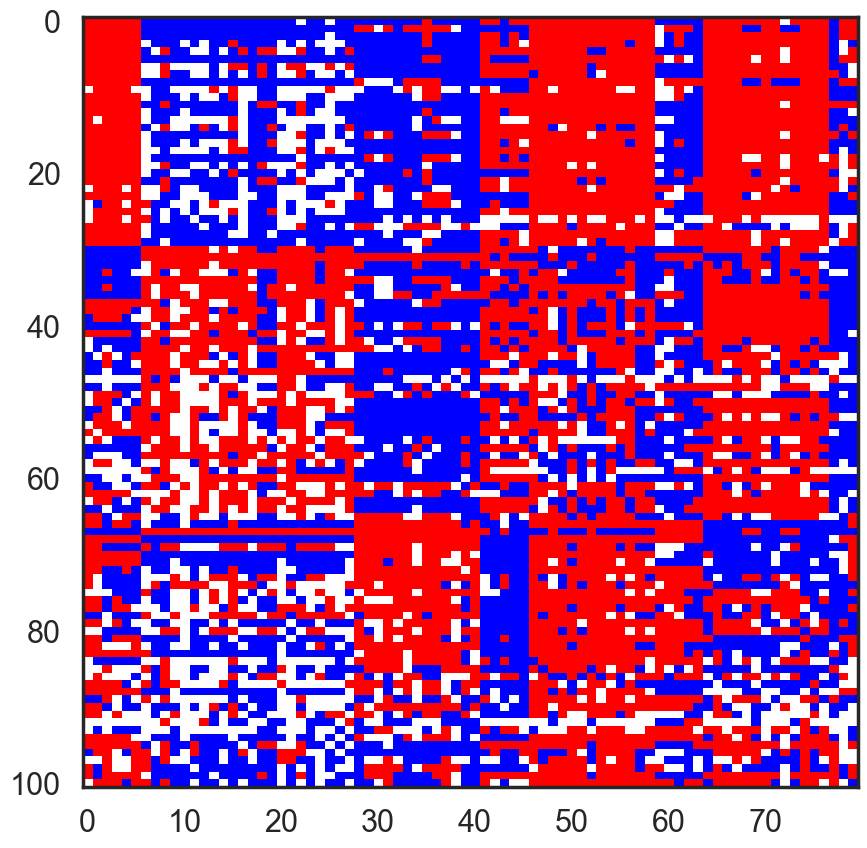

In [40]:
plt.figure(figsize=(10,10))
plt.imshow(dfr_pr.loc[:,np.hstack(hierarchical_states)],aspect="auto",cmap="bwr")

## Method 5: MINER F1 decomposition

In [41]:
t1 = time.time()
# select reference dictionary for downstream analysis (revisedClusters, coexpressionModules, or regulonModules)
referenceDictionary = regulonModules
# create a background matrix used for statistical hypothesis testing
bkgd = miner.backgroundDf(expressionData)
# for each cluster, give samples that show high coherent cluster activity
overExpressedMembers = miner.biclusterMembershipDictionary(referenceDictionary,bkgd,label=2,p=0.05)
# for each clus|ter, give samples that show low coherent cluster activity
underExpressedMembers = miner.biclusterMembershipDictionary(referenceDictionary,bkgd,label=0,p=0.05)

# write membership matrices to .csv file
overExpressedMembersMatrix = miner.membershipToIncidence(overExpressedMembers,expressionData)
overExpressedMembersMatrix.to_csv(os.path.join(resultsDirectory,"overExpressedMembers.csv"))
underExpressedMembersMatrix = miner.membershipToIncidence(underExpressedMembers,expressionData)
underExpressedMembersMatrix.to_csv(os.path.join(resultsDirectory,"underExpressedMembers.csv"))

t2 = time.time()
print("Completed patient mapping in {:.2f} minutes".format((t2-t1)/60.))

/Users/sanskrutik/Desktop/miner3/miner/src/miner_py3.py:1058: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  bkgd.iloc[:,i][bkgd.iloc[:,i]>=highCut]=1
/Users/sanskrutik/Desktop/miner3/miner/src/miner_py3.py:1059: FutureWarning: ChainedAssignm

done!
done!
Completed patient mapping in 0.13 minutes


In [42]:
#Suppress warnings
warnings.filterwarnings("ignore")

# Infer transcriptional states
minClusterSize = 5 #int(np.ceil(0.01*expressionData.shape[1]))
referenceMatrix = overExpressedMembersMatrix-underExpressedMembersMatrix
primaryMatrix = overExpressedMembersMatrix
primaryDictionary = overExpressedMembers
secondaryMatrix = underExpressedMembersMatrix
secondaryDictionary = underExpressedMembers

states_, centroidClusters = miner.inferSubtypes(referenceMatrix,primaryMatrix,secondaryMatrix,primaryDictionary,secondaryDictionary,minClusterSize = minClusterSize,restricted_index=None)
final_state = list(set(expressionData.columns)-set(np.hstack(states_)))
if len(final_state)>0:
    states_.append(final_state)
#miner.write_json(states_dictionary,os.path.join(resultsDirectory,"transcriptional_states.json"))

Beginning subtype inference
completed subtype inference in 0.01 minutes


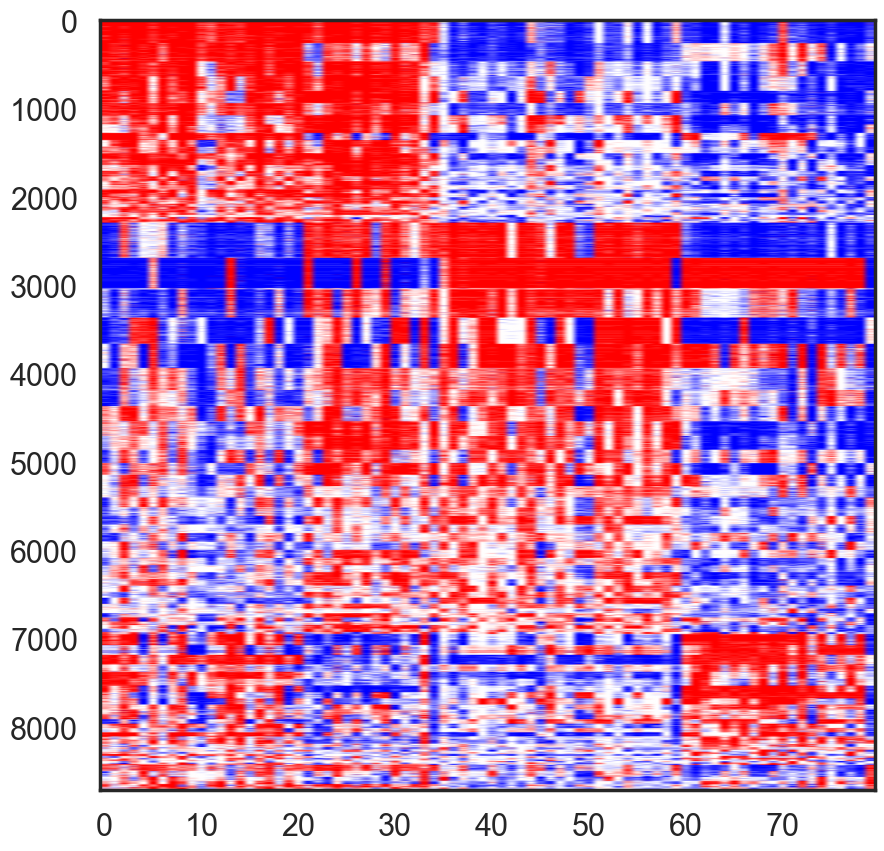

In [43]:
plt.figure(figsize=(10,10))
plt.imshow(diff_matrix_MMRF.loc[np.hstack(program_list),np.hstack(states_)],aspect="auto",cmap="bwr")
plt.grid(False)
plt.savefig(os.path.join(resultsDirectory, 'miner_f1_clusters.png'), format='png', dpi=150, bbox_inches='tight')

In [44]:
for i in range(len(states_)):
    for j in range(len(states)):
        overlap = len(miner.intersect(states_[i],states[j]))/float(min(len(states_[i]),len(states[j])))
        if overlap >= 0.5:
            print("Alt. state {:d} matches State {:d} with {:.2f}% overlap".format(i,j,100.0*overlap))

Alt. state 0 matches State 0 with 100.00% overlap
Alt. state 1 matches State 1 with 100.00% overlap
Alt. state 2 matches State 2 with 100.00% overlap
Alt. state 2 matches State 3 with 100.00% overlap
Alt. state 3 matches State 4 with 100.00% overlap
Alt. state 4 matches State 5 with 100.00% overlap


## Plot clusters side-by-side

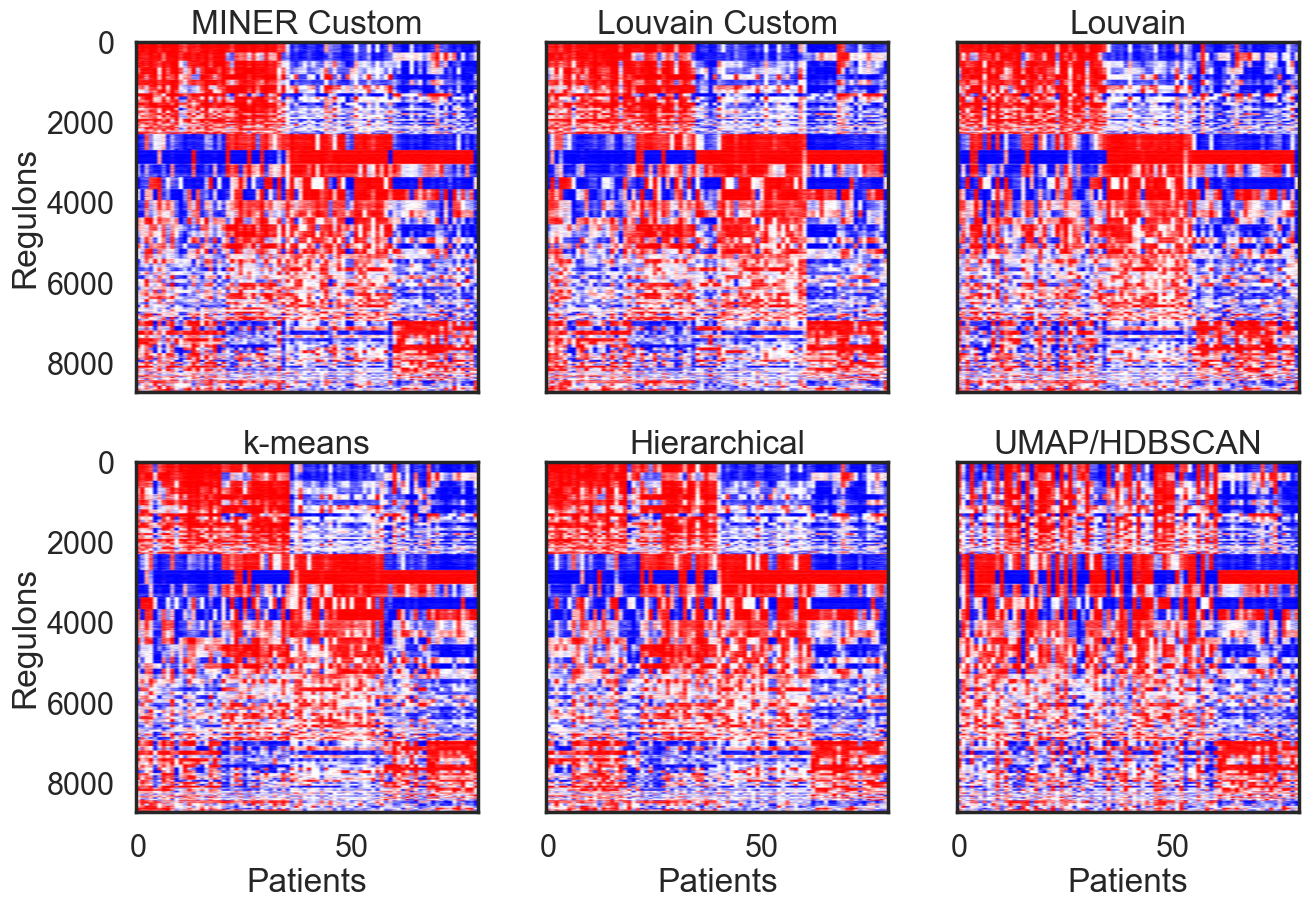

In [45]:
# Create figure with different clustering methods
fig, axs = plt.subplots(2, 3, sharey=True, sharex=True)
fig.set_figheight(10)
fig.set_figwidth(15)

#miner
axs[0, 0].imshow(diff_matrix_MMRF.loc[np.hstack(program_list),
                                       np.hstack(states)],aspect="auto",cmap="bwr")
axs[0, 0].set_title("MINER Custom")
axs[0, 0].set_ylabel("Regulons")

#louvain iterative
louvain_final_aligned = miner.align_to_reference(states_,louvain_final)
axs[0, 1].imshow(diff_matrix_MMRF.loc[np.hstack(program_list),
                                       np.hstack(louvain_final_aligned)],aspect="auto",cmap="bwr")
axs[0, 1].set_title("Louvain Custom")

#louvain
louvain_primary_aligned = miner.align_to_reference(states,louvain_primary)
axs[0, 2].imshow(diff_matrix_MMRF.loc[np.hstack(program_list),
                                       np.hstack(louvain_primary_aligned)],aspect="auto",cmap="bwr")
axs[0, 2].set_title("Louvain")

#kmeans
kmeans_aligned = miner.align_to_reference(states,kmeans_states)
axs[1, 0].imshow(diff_matrix_MMRF.loc[np.hstack(program_list),
                                       np.hstack(kmeans_aligned)],aspect="auto",cmap="bwr")
axs[1, 0].set_title("k-means")
axs[1, 0].set_ylabel("Regulons")
axs[1, 0].set_xlabel("Patients")

#hierarchical
hierarchical_aligned = miner.align_to_reference(states,hierarchical_states)
axs[1, 1].imshow(diff_matrix_MMRF.loc[np.hstack(program_list),
                                       np.hstack(hierarchical_aligned)],aspect="auto",cmap="bwr")
axs[1, 1].set_title("Hierarchical")
axs[1, 1].set_xlabel("Patients")

#hdbscan
hdbscan_aligned = miner.align_to_reference(states,hdbscan_states)
axs[1, 2].imshow(diff_matrix_MMRF.loc[np.hstack(program_list),
                                       np.hstack(hdbscan_aligned)],aspect="auto",cmap="bwr")
axs[1, 2].set_title("UMAP/HDBSCAN")
axs[1, 2].set_xlabel("Patients")

plt.savefig(os.path.join(resultsDirectory,"cluster_comparison_TCGA_UVM.png"),bbox_inches="tight", dpi=150)
plt.show()